In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from statsmodels.formula.api import ols   
from statsmodels.stats.anova import _get_covariance,anova_lm

## Problem 1

In [2]:
data = pd.read_csv('Fever-1.csv')

In [5]:
data.head()

,A,B,Volunteer,Relief
0,1,1,1,2.4
1,1,1,2,2.7
2,1,1,3,2.3
3,1,1,4,2.5
4,1,2,1,4.6


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
A            36 non-null int64
B            36 non-null int64
Volunteer    36 non-null int64
Relief       36 non-null float64
dtypes: float64(1), int64(3)
memory usage: 1.2 KB


In [7]:
data.describe()

,A,B,Volunteer,Relief
count,36.000000,36.000000,36.000000,36.000000
mean,2.000000,2.000000,2.500000,7.183333
std,0.828079,0.828079,1.133893,3.272090
min,1.000000,1.000000,1.000000,2.300000
25%,1.000000,1.000000,1.750000,4.675000
50%,2.000000,2.000000,2.500000,6.000000
75%,3.000000,3.000000,3.250000,9.325000
max,3.000000,3.000000,4.000000,13.500000


In [13]:
data['A'].unique()

array([1, 2, 3], dtype=int64)

In [5]:
data['B'].unique()

array([1, 2, 3], dtype=int64)

### 1.1) State the Null and Alternate Hypothesis for conducting one-way ANOVA for both the variables ‘A’ and ‘B’ individually.

### A
* Null Hypothesis = The mean hours of Relief are equal for all three levels
* Alternate Hypothesis = Atleast one mean is not equal

### B
* Null Hypothesis = The mean hours of Relief are equal for all three levels
* Alternate Hypothesis = Atleast one mean is not equal

### 1.2) Perform one-way ANOVA for variable ‘A’ with respect to the variable ‘Relief’. State whether the Null Hypothesis is accepted or rejected based on the ANOVA results.

In [3]:
formula = 'Relief ~ C(A)'
model = ols(formula, data).fit()
aov_table = anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq          F        PR(>F)
C(A)       2.0  220.02  110.010000  23.465387  4.578242e-07
Residual  33.0  154.71    4.688182        NaN           NaN


* since P-value is lower than the significant level the null hypothesis is rejected for variable B, there are differences in the mean hours of relief in variable A

### 1.3) Perform one-way ANOVA for variable ‘B’ with respect to the variable ‘Relief’. State whether the Null Hypothesis is accepted or rejected based on the ANOVA results.

In [19]:
formula = 'Relief ~ C(B)'
model = ols(formula, data).fit()
aov_table = anova_lm(model)
print(aov_table)

            df  sum_sq    mean_sq         F   PR(>F)
C(B)       2.0  123.66  61.830000  8.126777  0.00135
Residual  33.0  251.07   7.608182       NaN      NaN


* since P-value is lower than the significant level the null hypothesis is rejected for variable B, there are differences in the mean hours of relief in variable B

### 1.4) Analyse the effects of one variable on another with the help of an interaction plot. What is an interaction between two treatments?

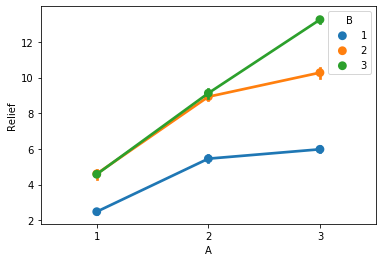

In [22]:
sns.pointplot(x='A', y='Relief', data=data, hue='B')

* For variable A almost none of the treatments seem to be equal as the points are not on a straight line
* for variable B levels 2 and 3 have a major interaction 

### 1.5) Perform a two-way ANOVA based on the different ingredients (variable ‘A’ & ‘B’) with the variable 'Relief' and state your results.

In [5]:
formula = 'Relief ~ C(A) + C(B)'
model = ols(formula, data).fit()
aov_table = anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq           F        PR(>F)
C(A)       2.0  220.02  110.010000  109.832850  8.514029e-15
C(B)       2.0  123.66   61.830000   61.730435  1.546749e-11
Residual  31.0   31.05    1.001613         NaN           NaN


* since the P-value is lower than the significant level we reject the null hypothesis that the mean hours of relief are equal

## Problem 2

In [10]:
df = pd.read_csv('Education - Post 12th Standard-1.csv')
Data = df.drop(['Names'],axis=1)

### 2.1) Perform Exploratory Data Analysis [both univariate and multivariate analysis to be performed]. The inferences drawn from this should be properly documented.

In [12]:
df.head().T

,0,1,2,3,4
Names,Abilene Christian University,Adelphi University,Adrian College,Agnes Scott College,Alaska Pacific University
Apps,1660,2186,1428,417,193
Accept,1232,1924,1097,349,146
Enroll,721,512,336,137,55
Top10perc,23,16,22,60,16
Top25perc,52,29,50,89,44
F.Undergrad,2885,2683,1036,510,249
P.Undergrad,537,1227,99,63,869
Outstate,7440,12280,11250,12960,7560
Room.Board,3300,6450,3750,5450,4120


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
Names          777 non-null object
Apps           777 non-null int64
Accept         777 non-null int64
Enroll         777 non-null int64
Top10perc      777 non-null int64
Top25perc      777 non-null int64
F.Undergrad    777 non-null int64
P.Undergrad    777 non-null int64
Outstate       777 non-null int64
Room.Board     777 non-null int64
Books          777 non-null int64
Personal       777 non-null int64
PhD            777 non-null int64
Terminal       777 non-null int64
S.F.Ratio      777 non-null float64
perc.alumni    777 non-null int64
Expend         777 non-null int64
Grad.Rate      777 non-null int64
dtypes: float64(1), int64(16), object(1)
memory usage: 109.4+ KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,3001.638353,3870.201484,81.0,776.0,1558.0,3624.0,48094.0
Accept,777.0,2018.804376,2451.113971,72.0,604.0,1110.0,2424.0,26330.0
Enroll,777.0,779.972973,929.176190,35.0,242.0,434.0,902.0,6392.0
Top10perc,777.0,27.558559,17.640364,1.0,15.0,23.0,35.0,96.0
Top25perc,777.0,55.796654,19.804778,9.0,41.0,54.0,69.0,100.0
F.Undergrad,777.0,3699.907336,4850.420531,139.0,992.0,1707.0,4005.0,31643.0
P.Undergrad,777.0,855.298584,1522.431887,1.0,95.0,353.0,967.0,21836.0
Outstate,777.0,10440.669241,4023.016484,2340.0,7320.0,9990.0,12925.0,21700.0
Room.Board,777.0,4357.526384,1096.696416,1780.0,3597.0,4200.0,5050.0,8124.0
Books,777.0,549.380952,165.105360,96.0,470.0,500.0,600.0,2340.0


In [11]:
df.shape

(777, 18)

In [13]:
dups = df.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

df[dups]

Number of duplicate rows = 0


,Names,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


In [16]:
df.isnull().sum()

Names          0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002B0DF665648>,
      dtype=object)

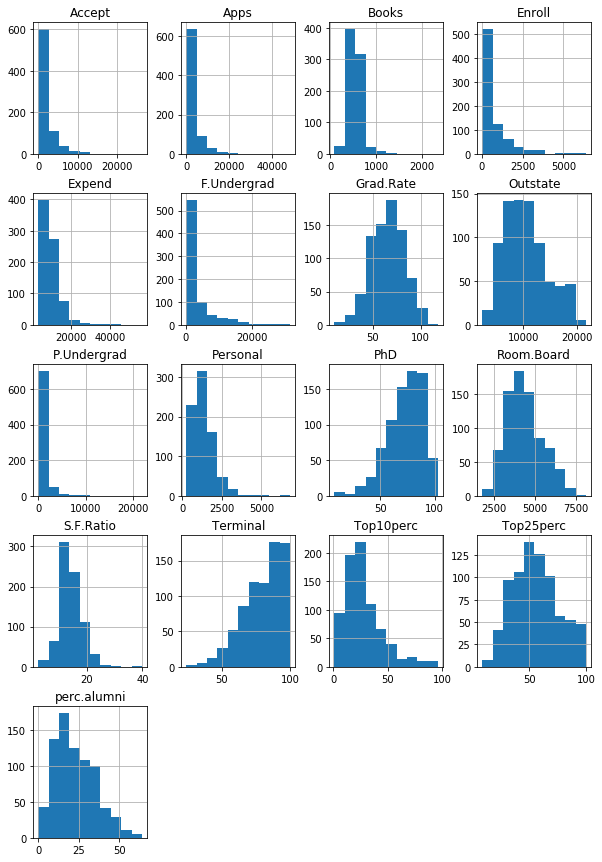

In [6]:
df.hist(figsize=(10,15))

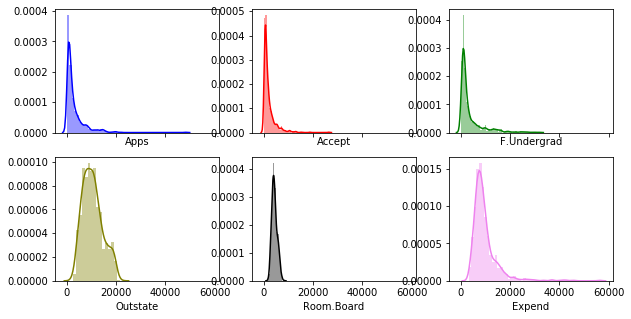

In [29]:
f, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True)
sns.distplot(Data['Apps'], color = 'Blue', label='Apps', ax=axes[0, 0])
sns.distplot(Data['Accept'], color = 'Red', label='Accept', ax=axes[0, 1])
sns.distplot(Data['F.Undergrad'], color = 'Green', label='F.Undergrad', ax=axes[0, 2])
sns.distplot(Data['Outstate'], color = 'Olive', label='Outstate', ax=axes[1, 0])
sns.distplot(Data['Room.Board'], color = 'Black', label='Room.Board', ax=axes[1, 1])
sns.distplot(Data['Expend'], color = 'violet', label='Expend', ax=axes[1, 2])

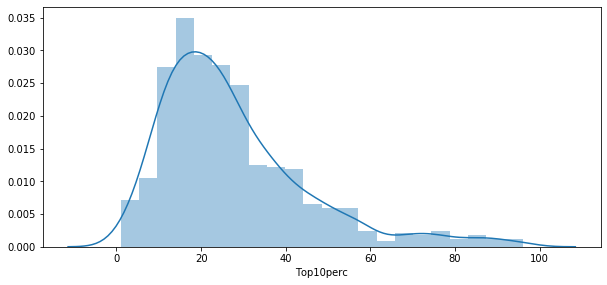

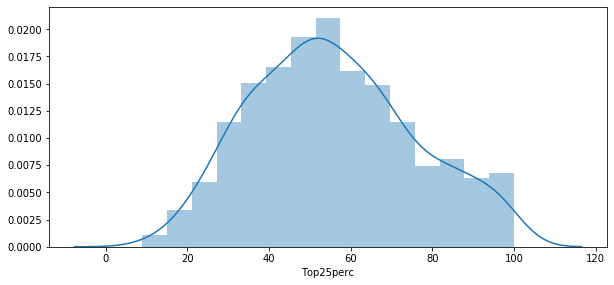

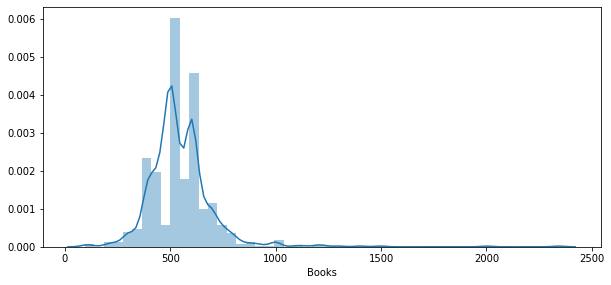

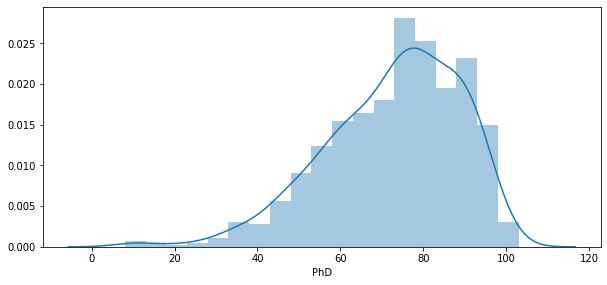

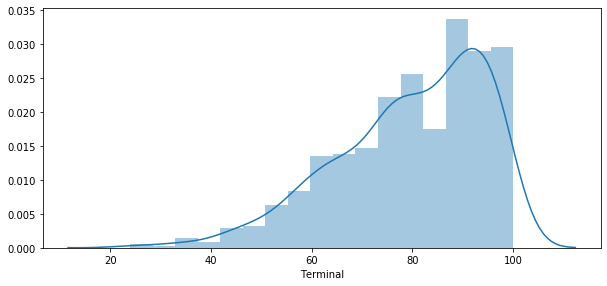

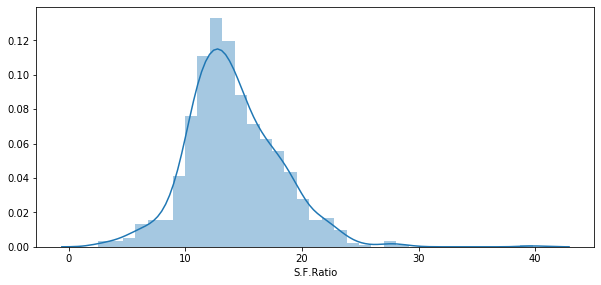

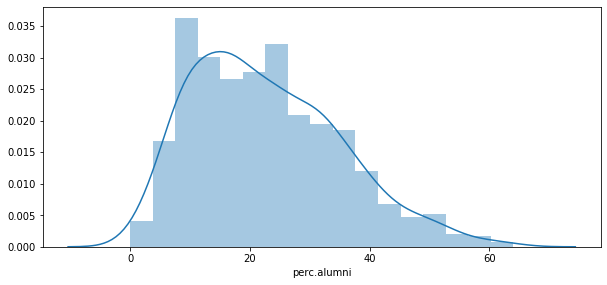

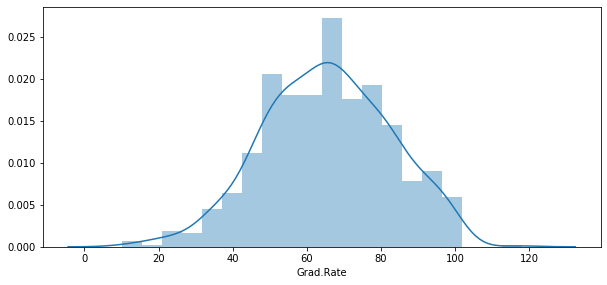

In [63]:
plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.distplot(df.Top10perc)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.distplot(df.Top25perc)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.distplot(df.Books)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.distplot(df.PhD)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.distplot(df.Terminal)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.distplot(df['S.F.Ratio'])

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.distplot(df['perc.alumni'])

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.distplot(df['Grad.Rate'])

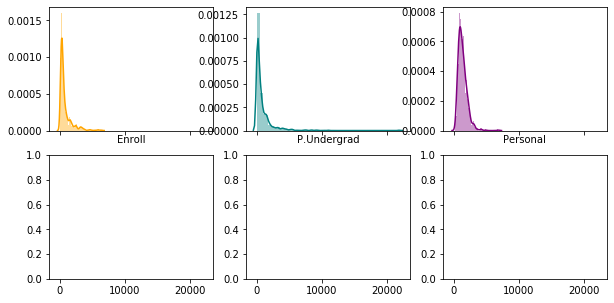

In [64]:
f, axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True)
sns.distplot(Data['Enroll'], color = 'Orange', label='Enroll', ax=axes[0, 0])
sns.distplot(Data['P.Undergrad'], color = 'Teal', label='P.Undergrad', ax=axes[0, 1])
sns.distplot(Data['Personal'], color = 'purple', label='Personal', ax=axes[0, 2])

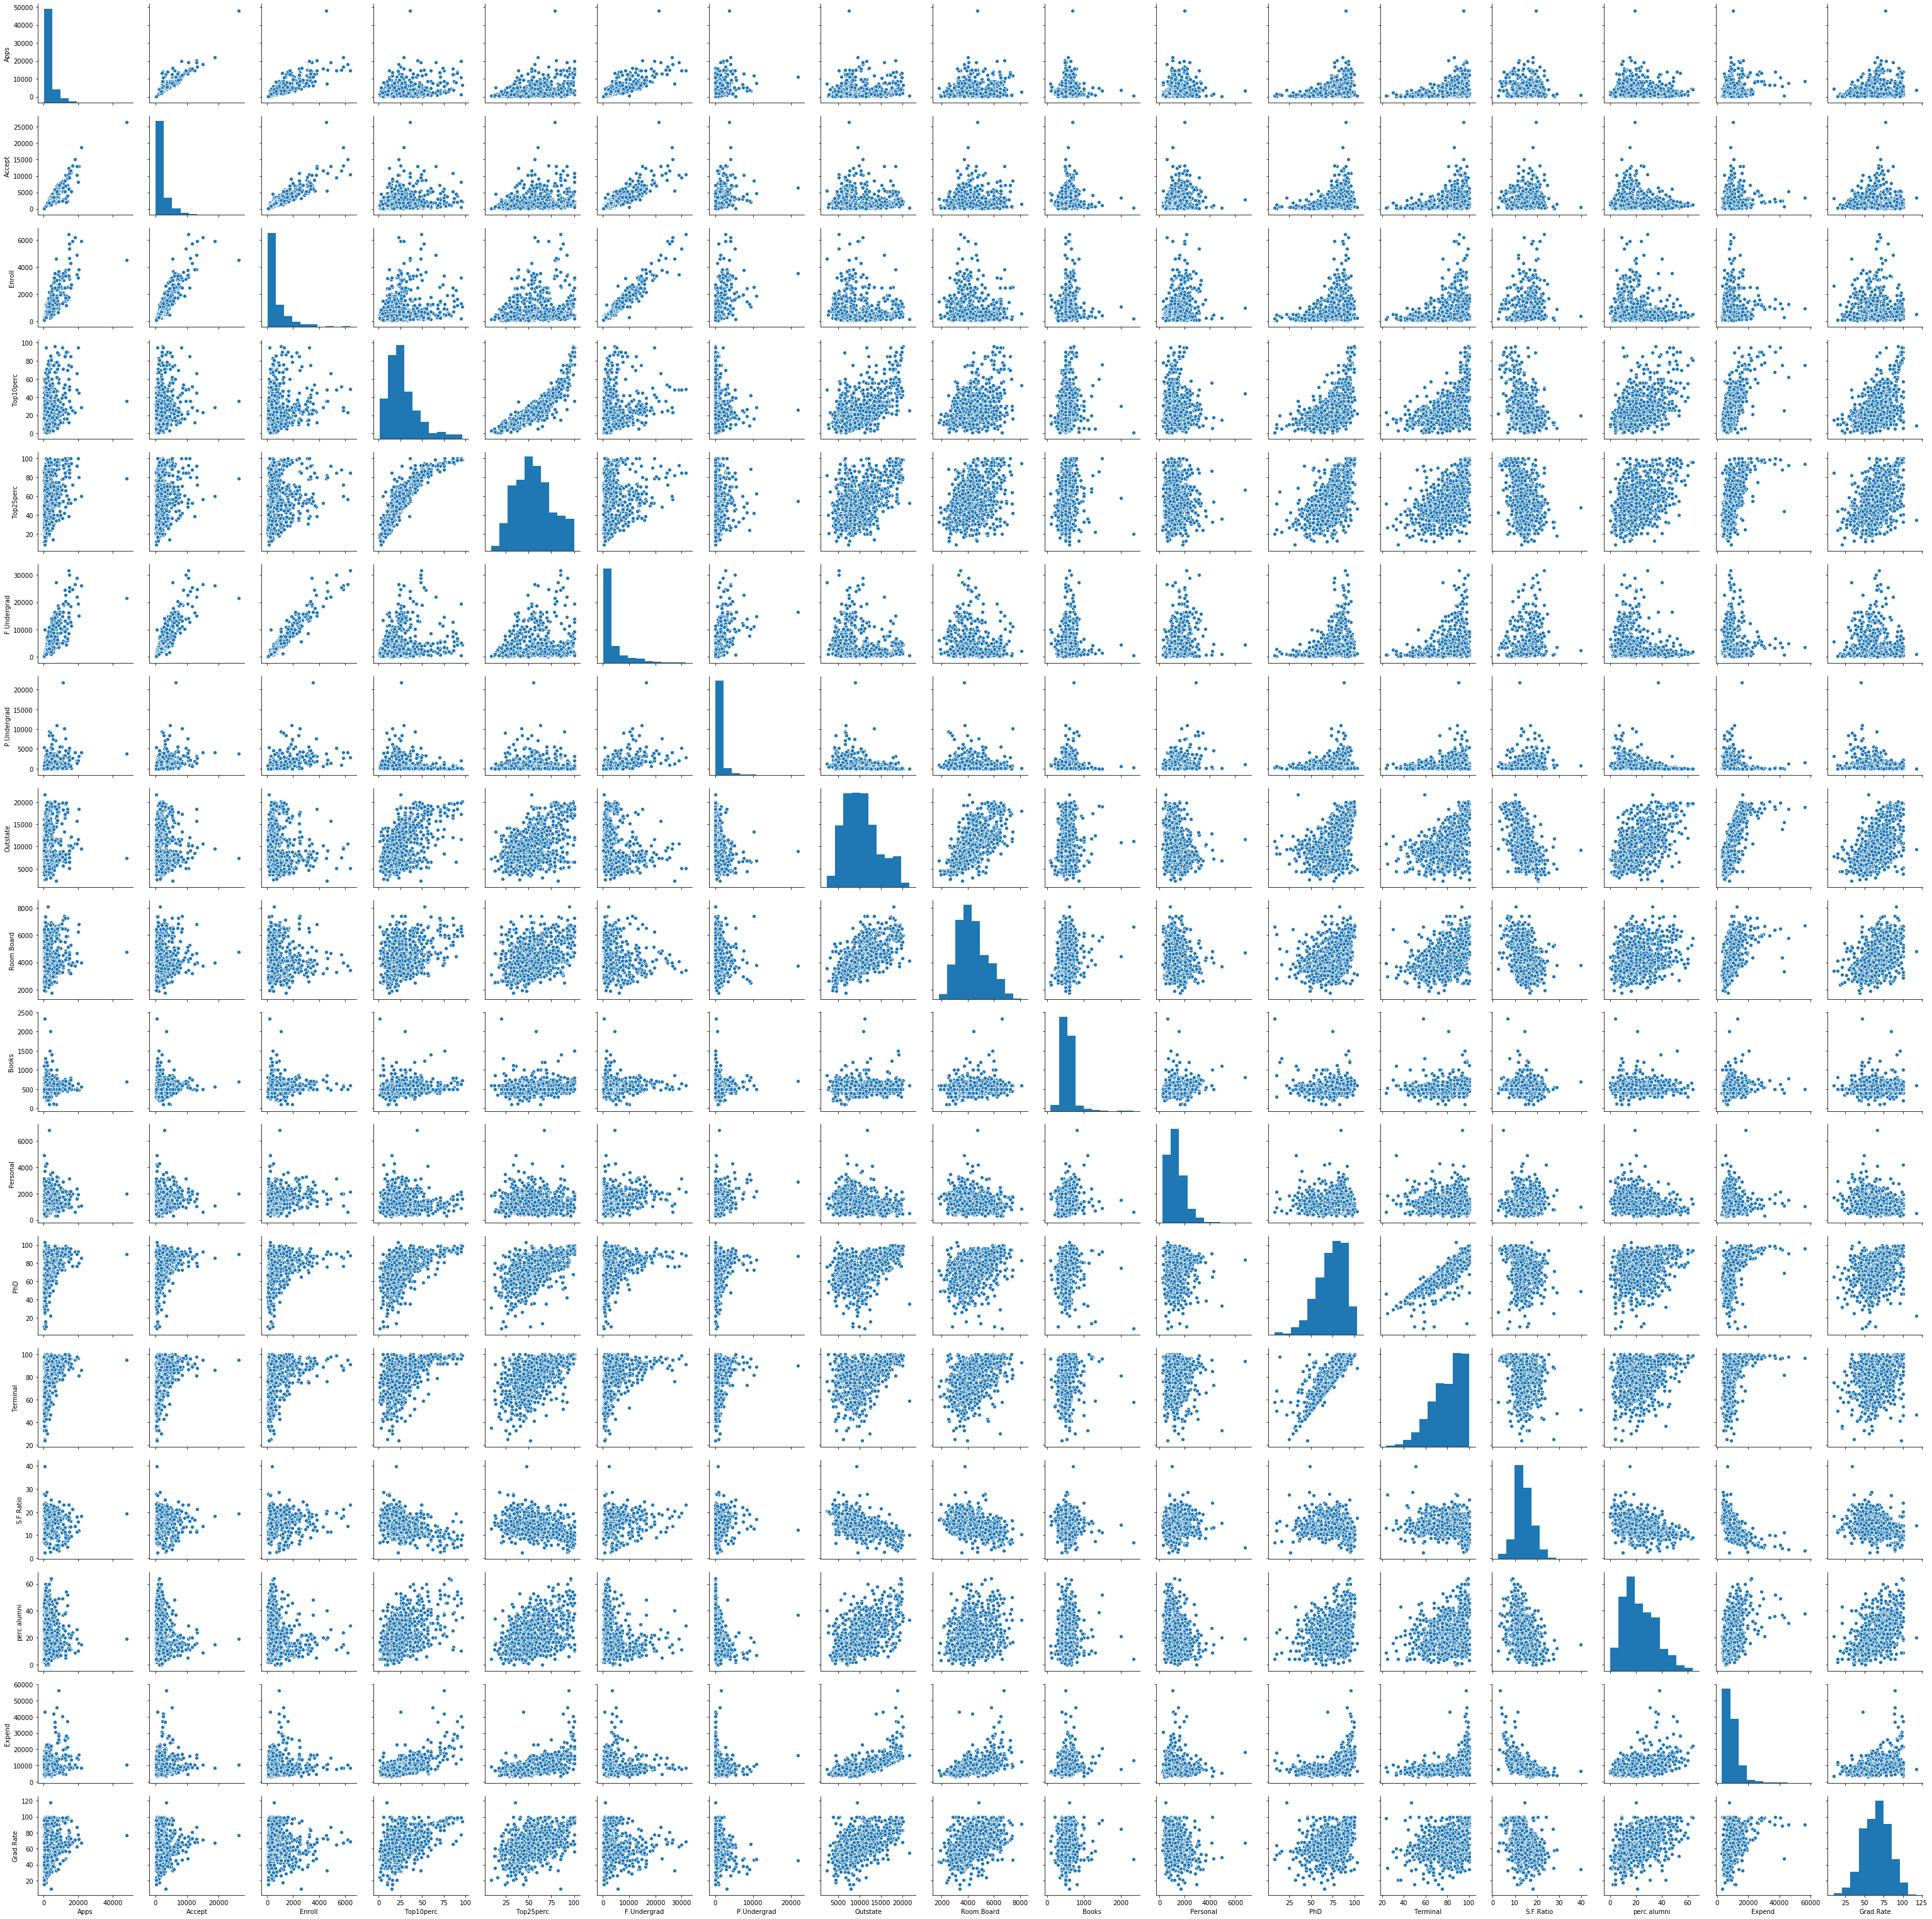

In [48]:
sns.pairplot(df)

In [18]:
df.corr()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Apps,1.000000,0.943451,0.846822,0.338834,0.351640,0.814491,0.398264,0.050159,0.164939,0.132559,0.178731,0.390697,0.369491,0.095633,-0.090226,0.259592,0.146755
Accept,0.943451,1.000000,0.911637,0.192447,0.247476,0.874223,0.441271,-0.025755,0.090899,0.113525,0.200989,0.355758,0.337583,0.176229,-0.159990,0.124717,0.067313
Enroll,0.846822,0.911637,1.000000,0.181294,0.226745,0.964640,0.513069,-0.155477,-0.040232,0.112711,0.280929,0.331469,0.308274,0.237271,-0.180794,0.064169,-0.022341
Top10perc,0.338834,0.192447,0.181294,1.000000,0.891995,0.141289,-0.105356,0.562331,0.371480,0.118858,-0.093316,0.531828,0.491135,-0.384875,0.455485,0.660913,0.494989
Top25perc,0.351640,0.247476,0.226745,0.891995,1.000000,0.199445,-0.053577,0.489394,0.331490,0.115527,-0.080810,0.545862,0.524749,-0.294629,0.417864,0.527447,0.477281
F.Undergrad,0.814491,0.874223,0.964640,0.141289,0.199445,1.000000,0.570512,-0.215742,-0.068890,0.115550,0.317200,0.318337,0.300019,0.279703,-0.229462,0.018652,-0.078773
P.Undergrad,0.398264,0.441271,0.513069,-0.105356,-0.053577,0.570512,1.000000,-0.253512,-0.061326,0.081200,0.319882,0.149114,0.141904,0.232531,-0.280792,-0.083568,-0.257001
Outstate,0.050159,-0.025755,-0.155477,0.562331,0.489394,-0.215742,-0.253512,1.000000,0.654256,0.038855,-0.299087,0.382982,0.407983,-0.554821,0.566262,0.672779,0.571290
Room.Board,0.164939,0.090899,-0.040232,0.371480,0.331490,-0.068890,-0.061326,0.654256,1.000000,0.127963,-0.199428,0.329202,0.374540,-0.362628,0.272363,0.501739,0.424942
Books,0.132559,0.113525,0.112711,0.118858,0.115527,0.115550,0.081200,0.038855,0.127963,1.000000,0.179295,0.026906,0.099955,-0.031929,-0.040208,0.112409,0.001061


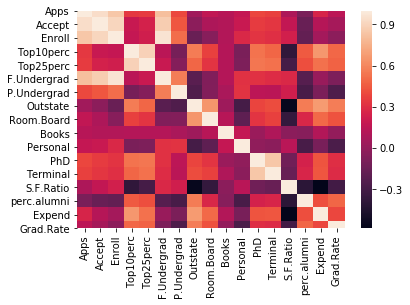

In [19]:
sns.heatmap(df.corr())

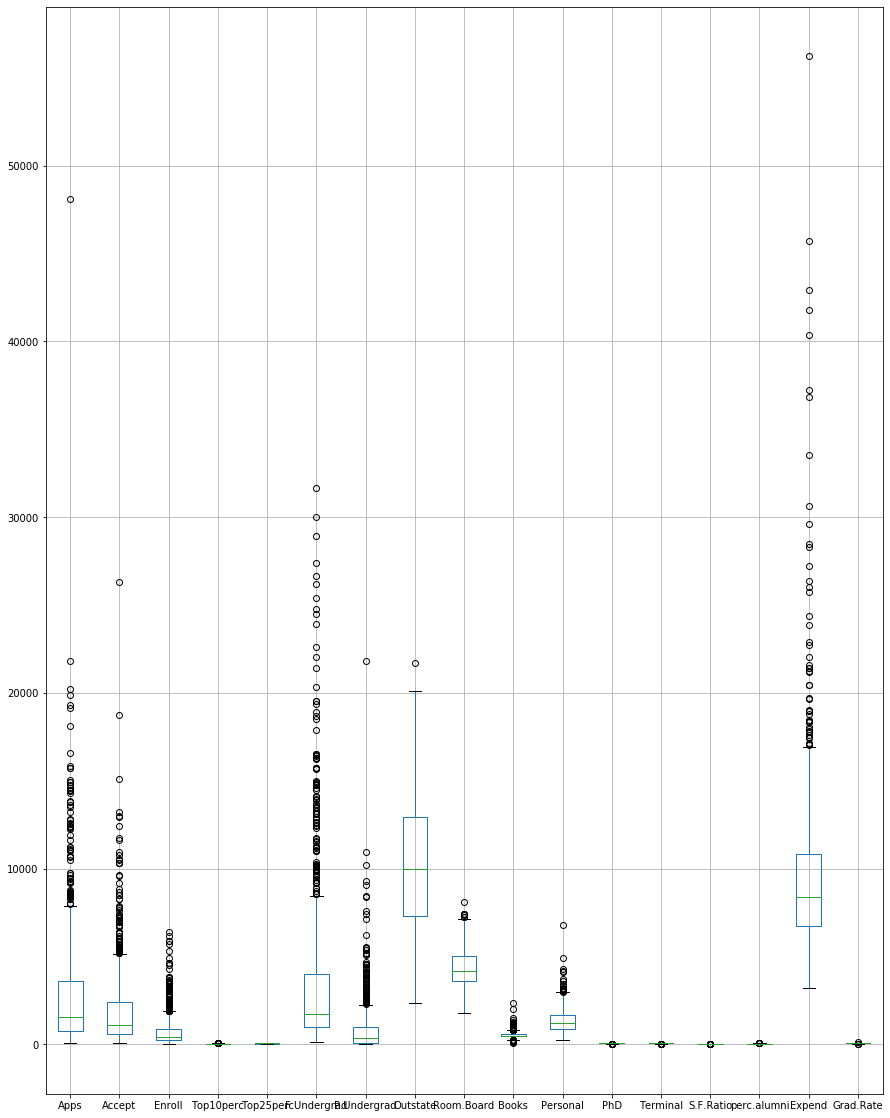

In [9]:
plt.figure(figsize = (15,20))
df.boxplot()

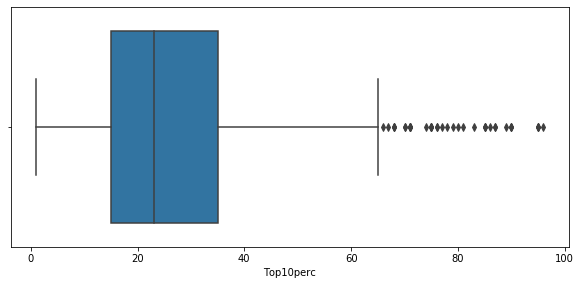

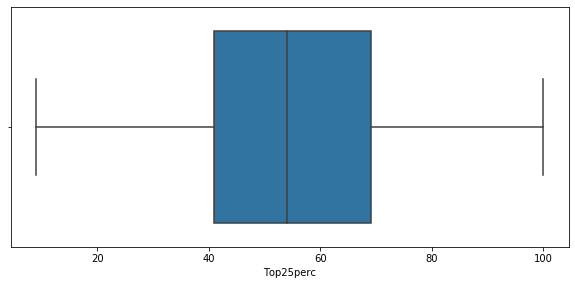

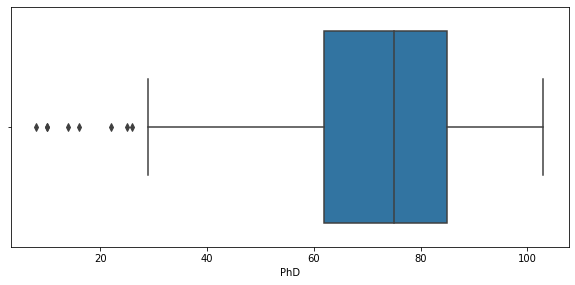

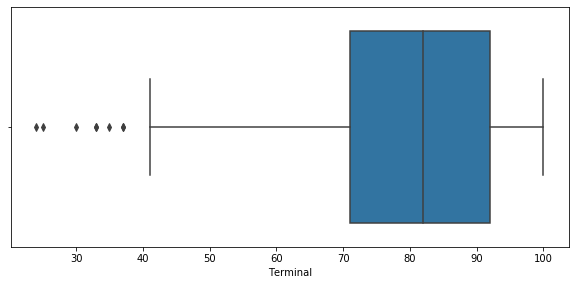

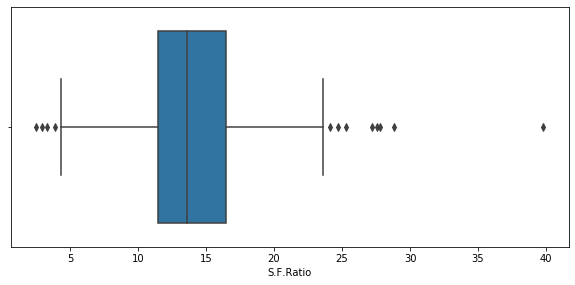

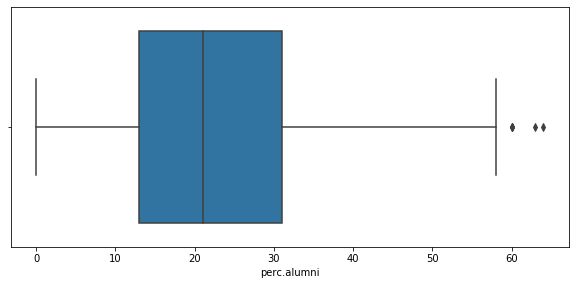

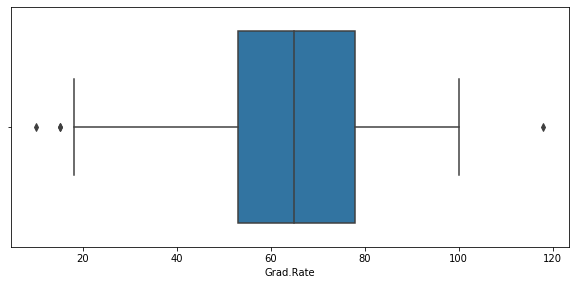

In [53]:
plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.boxplot(x = df.Top10perc)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.boxplot(x = df.Top25perc)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.boxplot(x = df.PhD)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.boxplot(x = df.Terminal)

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.boxplot(x = df['S.F.Ratio'])

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.boxplot(x = df['perc.alumni'])

plt.figure(figsize = (10,15))
plt.subplot(3,1,1)
sns.boxplot(x = df['Grad.Rate'])

In [65]:
from sklearn.preprocessing import StandardScaler
std_scale = StandardScaler()
std_scale

StandardScaler(copy=True, with_mean=True, with_std=True)

### 2.2) Scale the variables and write the inference for using the type of scaling function for this case study.

In [66]:
from scipy.stats import zscore
Data_PCA=Data.apply(zscore)
Data_PCA.head().T

,0,1,2,3,4
Apps,-0.346882,-0.210884,-0.406866,-0.668261,-0.726176
Accept,-0.321205,-0.038703,-0.376318,-0.681682,-0.764555
Enroll,-0.063509,-0.288584,-0.478121,-0.692427,-0.780735
Top10perc,-0.258583,-0.655656,-0.315307,1.840231,-0.655656
Top25perc,-0.191827,-1.353911,-0.292878,1.677612,-0.596031
F.Undergrad,-0.168116,-0.209788,-0.549565,-0.658079,-0.711924
P.Undergrad,-0.209207,0.244307,-0.497090,-0.520752,0.009005
Outstate,-0.746356,0.457496,0.201305,0.626633,-0.716508
Room.Board,-0.964905,1.909208,-0.554317,0.996791,-0.216723
Books,-0.602312,1.215880,-0.905344,-0.602312,1.518912


### 2.4) Check the dataset for outliers before and after scaling. Draw your inferences from this exercise.

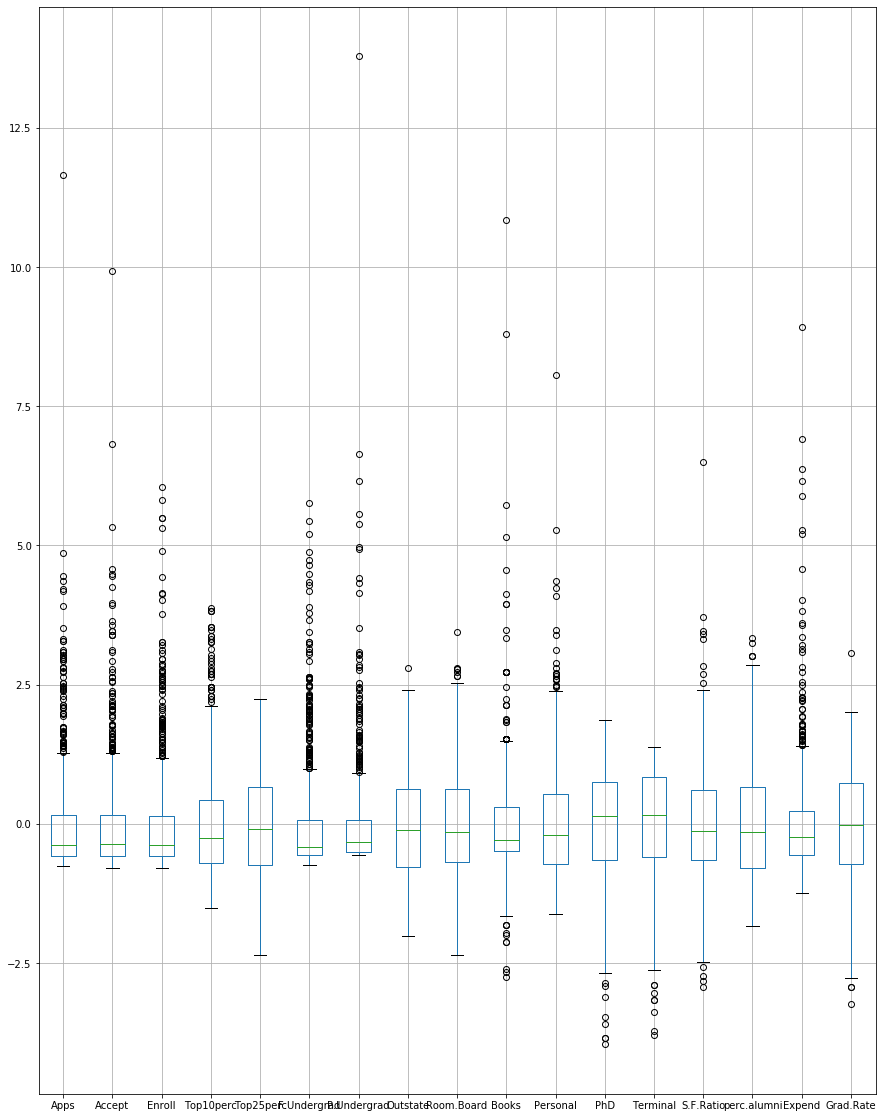

In [25]:
plt.figure(figsize = (15,20))
Data_PCA.boxplot()

### 2.5) Build the covariance matrix, eigenvalues and eigenvector.

In [69]:
cov_matrix=np.cov(Data_PCA.T)
cov_matrix

array([[ 1.00128866,  0.94466636,  0.84791332,  0.33927032,  0.35209304,
         0.81554018,  0.3987775 ,  0.05022367,  0.16515151,  0.13272942,
         0.17896117,  0.39120081,  0.36996762,  0.09575627, -0.09034216,
         0.2599265 ,  0.14694372],
       [ 0.94466636,  1.00128866,  0.91281145,  0.19269493,  0.24779465,
         0.87534985,  0.44183938, -0.02578774,  0.09101577,  0.11367165,
         0.20124767,  0.35621633,  0.3380184 ,  0.17645611, -0.16019604,
         0.12487773,  0.06739929],
       [ 0.84791332,  0.91281145,  1.00128866,  0.18152715,  0.2270373 ,
         0.96588274,  0.51372977, -0.1556777 , -0.04028353,  0.11285614,
         0.28129148,  0.33189629,  0.30867133,  0.23757707, -0.18102711,
         0.06425192, -0.02236983],
       [ 0.33927032,  0.19269493,  0.18152715,  1.00128866,  0.89314445,
         0.1414708 , -0.10549205,  0.5630552 ,  0.37195909,  0.1190116 ,
        -0.09343665,  0.53251337,  0.49176793, -0.38537048,  0.45607223,
         0.6617651 

In [70]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-2.48765602e-01  3.31598227e-01  6.30921033e-02 -2.81310530e-01
   5.74140964e-03  1.62374420e-02  4.24863486e-02  1.03090398e-01
   9.02270802e-02 -5.25098025e-02  3.58970400e-01 -4.59139498e-01
   4.30462074e-02 -1.33405806e-01  8.06328039e-02 -5.95830975e-01
   2.40709086e-02]
 [-2.07601502e-01  3.72116750e-01  1.01249056e-01 -2.67817346e-01
   5.57860920e-02 -7.53468452e-03  1.29497196e-02  5.62709623e-02
   1.77864814e-01 -4.11400844e-02 -5.43427250e-01  5.18568789e-01
  -5.84055850e-02  1.45497511e-01  3.34674281e-02 -2.92642398e-01
  -1.45102446e-01]
 [-1.76303592e-01  4.03724252e-01  8.29855709e-02 -1.61826771e-01
  -5.56936353e-02  4.25579803e-02  2.76928937e-02 -5.86623552e-02
   1.28560713e-01 -3.44879147e-02  6.09651110e-01  4.04318439e-01
  -6.93988831e-02 -2.95896092e-02 -8.56967180e-02  4.44638207e-01
   1.11431545e-02]
 [-3.54273947e-01 -8.24118211e-02 -3.50555339e-02  5.15472524e-02
  -3.95434345e-01  5.26927980e-02  1.61332069e-01  1.22678028e-01
 

In [71]:
tot = sum(eig_vals)
tot

17.021907216494842

### 2.7) Discuss the cumulative values of the eigenvalues. How does it help you to decide on the optimum number of principal components? What do the eigenvectors indicate?
Perform PCA and export the data of the Principal Component scores into a data frame.

In [28]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
print(var_exp)
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

[32.020628198869176, 26.340214436112475, 6.9009165542224995, 5.922989222926297, 5.488405110358475, 4.984700954557443, 3.558871491746638, 3.453621336999256, 3.1172336798217124, 2.3751915258937935, 1.8414263209386847, 1.2960414001235347, 0.9857541228001162, 0.8458423350830019, 0.5171255833731941, 0.21575401007275563, 0.13528371610095216]
Cumulative Variance Explained [ 32.0206282   58.36084263  65.26175919  71.18474841  76.67315352
  81.65785448  85.21672597  88.67034731  91.78758099  94.16277251
  96.00419883  97.30024023  98.28599436  99.13183669  99.64896227
  99.86471628 100.        ]


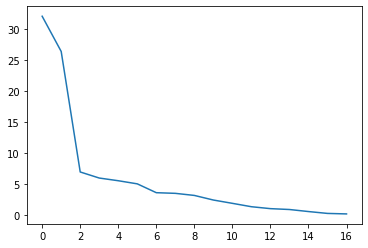

In [29]:
plt.plot(var_exp)

In [78]:
from sklearn.decomposition import PCA
pca = PCA(n_components=6)
data_reduced = pca.fit_transform(Data_PCA)
data_reduced.transpose()

array([[-1.59285540e+00, -2.19240180e+00, -1.43096371e+00, ...,
        -7.32560596e-01,  7.91932735e+00, -4.69508066e-01],
       [ 7.67333510e-01, -5.78829984e-01, -1.09281889e+00, ...,
        -7.72352397e-02, -2.06832886e+00,  3.66660943e-01],
       [-1.01073562e-01,  2.27879816e+00, -4.38092812e-01, ...,
        -4.05621328e-04,  2.07356361e+00, -1.32891515e+00],
       [-9.21749402e-01,  3.58891824e+00,  6.77240527e-01, ...,
         5.43162837e-02,  8.52053985e-01, -1.08022557e-01],
       [-7.43975458e-01,  1.05999671e+00, -3.69613277e-01, ...,
        -5.16021068e-01, -9.47754934e-01, -1.13217594e+00],
       [-2.98306261e-01, -1.77137001e-01, -9.60591696e-01, ...,
         4.68014399e-01, -2.06993795e+00,  8.39893077e-01]])

In [12]:
var= pca.explained_variance_ratio_
var

array([0.32020628, 0.26340214, 0.06900917, 0.05922989, 0.05488405,
       0.04984701])

In [92]:
data_scaled = Data_PCA

pca = PCA(n_components=1)
pca.fit_transform(data_scaled)

df_PC =pd.DataFrame(pca.components_,columns=Data_PCA.columns,index = ['PC-1'])

In [97]:
df_PC.T

,PC-1
Apps,0.248766
Accept,0.207602
Enroll,0.176304
Top10perc,0.354274
Top25perc,0.344001
F.Undergrad,0.154641
P.Undergrad,0.026443
Outstate,0.294736
Room.Board,0.249030
Books,0.064758


In [18]:
pca.components_

array([[ 0.2487656 ,  0.2076015 ,  0.17630359,  0.35427395,  0.34400128,
         0.15464096,  0.0264425 ,  0.29473642,  0.24903045,  0.06475752,
        -0.04252854,  0.31831287,  0.31705602, -0.17695789,  0.20508237,
         0.31890875,  0.25231565]])

In [83]:
series1=df_PC.iloc[0]
series1

Apps           0.248766
Accept         0.207602
Enroll         0.176304
Top10perc      0.354274
Top25perc      0.344001
F.Undergrad    0.154641
P.Undergrad    0.026443
Outstate       0.294736
Room.Board     0.249030
Books          0.064758
Personal      -0.042529
PhD            0.318313
Terminal       0.317056
S.F.Ratio     -0.176958
perc.alumni    0.205082
Expend         0.318909
Grad.Rate      0.252316
Name: PC-1, dtype: float64

In [81]:
func2 = lambda x: x*series1

In [84]:
Data_PCA1=data_scaled.apply(func2, axis=1)
Data_PCA1

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,-0.086292,-0.066683,-0.011197,-0.091609,-0.065989,-0.025998,-0.005532,-0.219978,-0.240291,-0.039004,-0.054013,-0.051894,-0.036692,-0.179396,-0.177924,-0.160064,-0.080300
1,-0.052461,-0.008035,-0.050878,-0.232282,-0.465747,-0.032442,0.006460,0.134841,0.475451,0.078737,-0.010016,-0.851692,-1.071071,0.084534,-0.111682,0.052974,-0.139092
2,-0.101214,-0.078124,-0.084295,-0.111705,-0.100750,-0.084985,-0.013144,0.059332,-0.138042,-0.058628,0.011040,-0.383518,-0.295287,0.053220,0.120165,-0.056539,-0.168488
3,-0.166240,-0.141518,-0.122077,0.651946,0.577101,-0.101766,-0.013770,0.184691,0.248231,-0.039004,0.029267,0.377266,0.372749,0.285836,0.236088,0.571756,-0.094998
4,-0.180648,-0.158723,-0.137646,-0.232282,-0.205035,-0.110093,0.000238,-0.211181,-0.053971,0.098361,-0.010016,0.065150,-0.165990,0.097954,-0.343529,0.077113,-0.741710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,-0.051753,-0.042698,-0.044993,-0.473435,-0.517890,-0.019489,0.020399,-0.267116,-0.103959,-0.019381,0.008840,-0.246967,-0.424584,-0.309124,-0.144803,-0.317244,-0.374260
773,-0.067061,-0.018120,-0.016133,-0.071513,-0.152893,-0.027146,0.004375,0.079125,0.136894,0.019867,0.005697,0.006628,-0.101341,0.035326,0.136725,-0.028794,0.257754
774,-0.058185,-0.008798,-0.016133,0.129448,0.090438,-0.028933,-0.011980,-0.259566,-0.035793,0.026539,0.035175,-0.110416,-0.101341,-0.013881,-0.045440,-0.081718,-0.241978
775,0.495469,0.036799,0.101962,1.355308,0.750909,0.048399,-0.013422,0.689062,0.489084,0.031641,-0.048671,0.455295,0.351199,0.370830,0.434814,1.877725,0.492922


In [87]:
Data['PCA_score']=Data_PCA1.sum(axis = 1, skipna = True) 

In [88]:
Data.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,PCA_score
0,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,-1.592855
1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,-2.192402
2,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,-1.430964
3,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,2.855557
4,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,-2.212008
